# Run PCA and GMM on Core Argo 

In [1]:
from importlib import reload
import mod_loading as loader
import mod_pca


[coreDS, coreINDEX, bgcDS, bgcINDEX, socat] = loader.import_data(type=['core', 'bgc', 'socat'])

In [2]:
### CHOOSE RUN PARAMETERS ### ===================

n_pca = 8               # PC components 
n_gmm = 8               # GMM classes 
dbar_limit = 501        # Depth limit for PCA 

# ================================================

In [3]:
# Preprocessing core Argo data
reload(mod_pca)
centered_coreDS = mod_pca.center_byPressure(coreDS, with_scaling = False)

/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/opt/homebrew/Caskroom/mambaforge/base/envs/cremas/lib/p

In [4]:
# Main PCA and GMM function
reload(mod_pca)
[Xtrain, Xtrans, pca_obj, PCdict, gmm, Y_gmm, class_locs, class_data] = mod_pca.run_pca_and_gmm(
                                                                centered_coreDS, coreDS, coreINDEX,
                                                                n_pca=n_pca, 
                                                                n_gmm=n_gmm, 
                                                                dbar_limit=dbar_limit
                                                            )

# Calculate posterior probabilities for each class
probs, class_probs = mod_pca.calc_postprobs(gmm, Xtrain, Xtrans, Y_gmm, class_locs)


n_PCs: 8 	explained_variance: 0.9965087951093308
Number of profiles by class
class 1 : 43238
class 2 : 60514
class 3 : 43498
class 4 : 55335
class 5 : 44314
class 6 : 19380
class 7 : 27087
class 8 : 25578


## Class locations

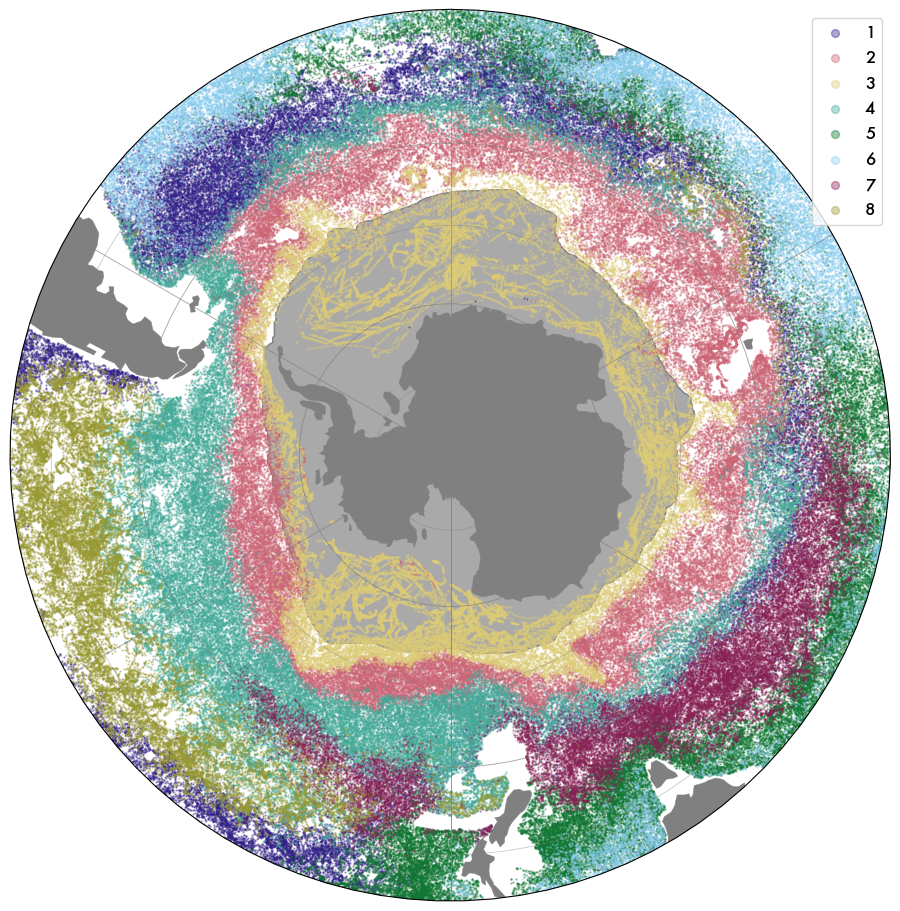

In [5]:
import figs_pcm 
from importlib import reload
reload(figs_pcm)

# To plot all classes on one plot
figs_pcm.sopolar_classes(class_locs, inds=range(8), figsize=(9,9))

# To plot two classes, 1 and 4 *** Notice indices are class-1
# figs_pcm.sopolar_classes(class_locs, inds=[0, 3], figsize=(9,9))

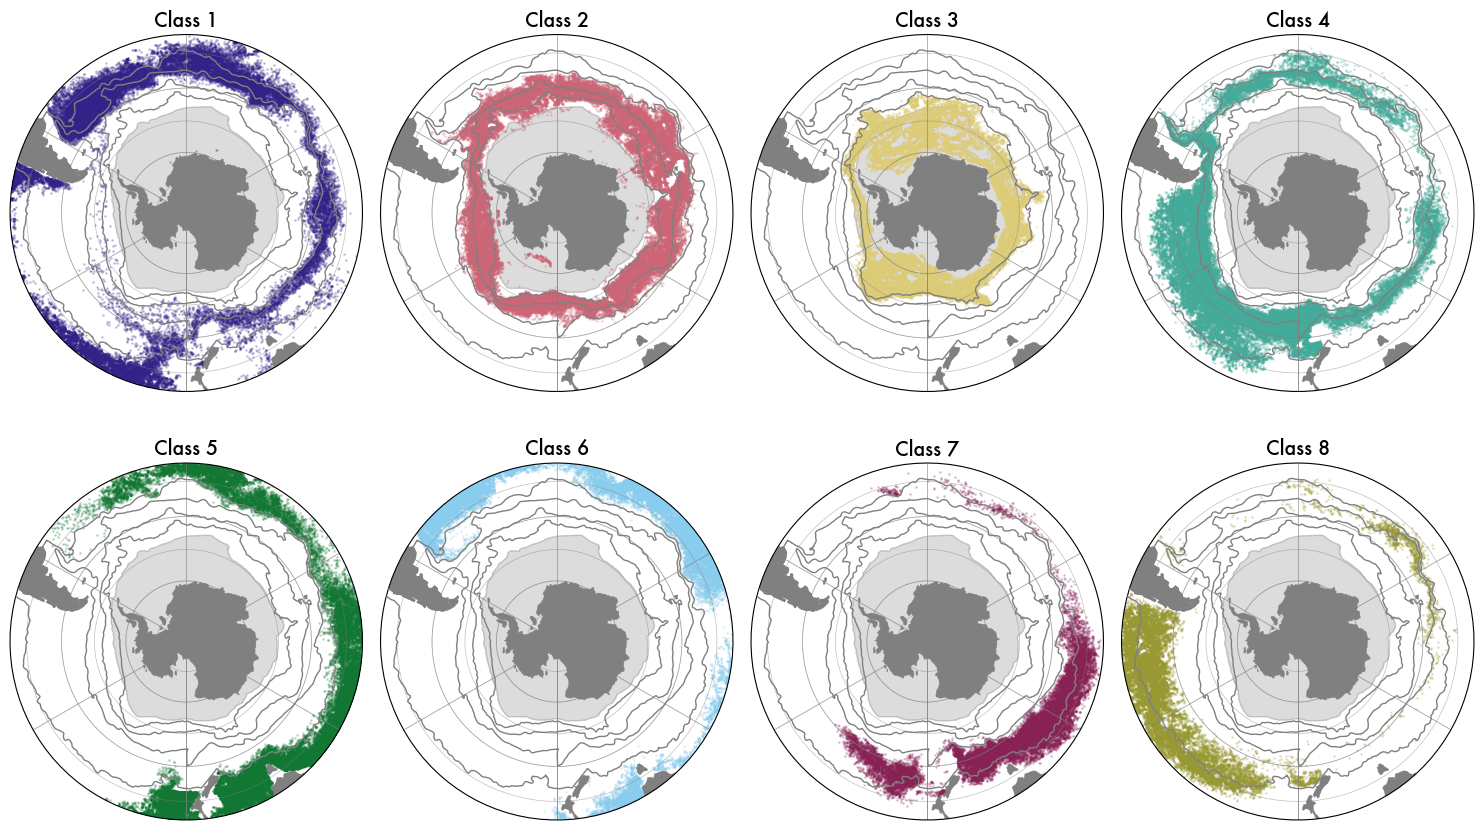

In [6]:
reload(figs_pcm)
figs_pcm.sopolar_classes_paneled(class_locs, figsize=(9,9))

## Mean profiles by class

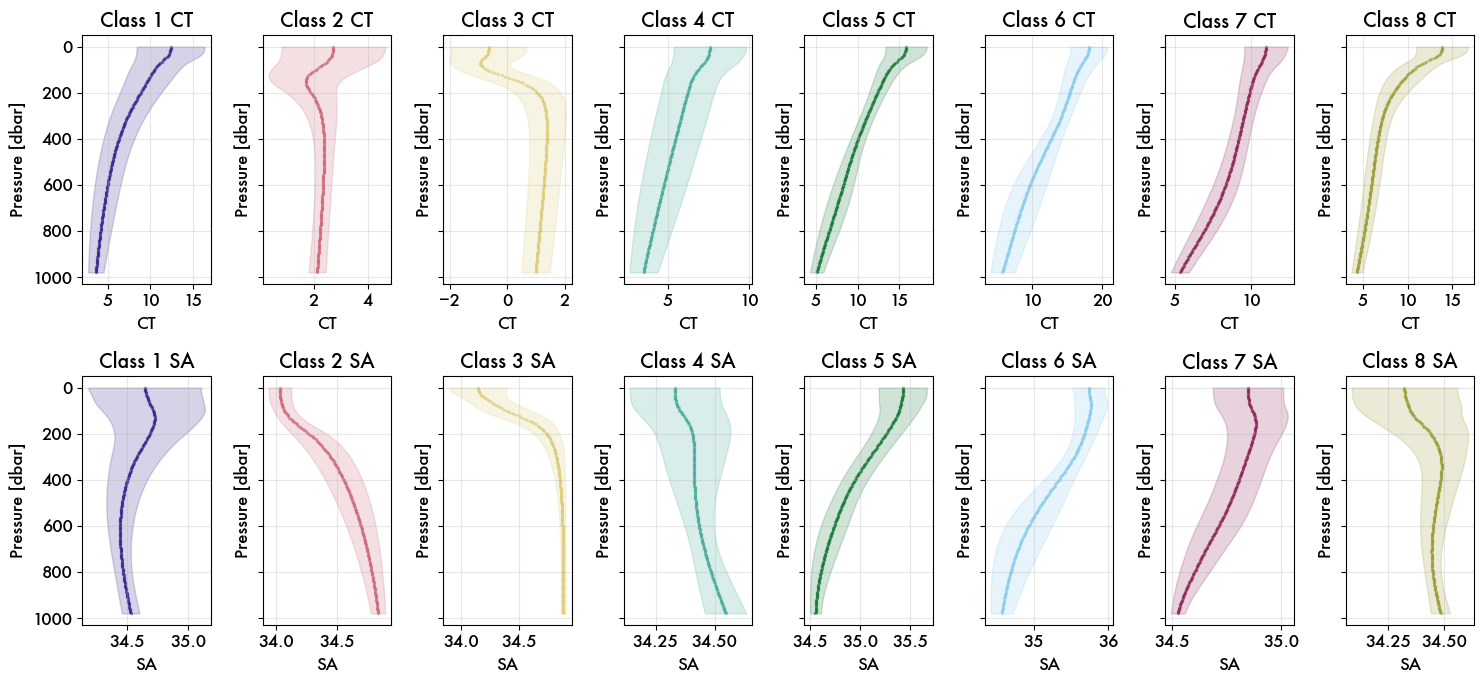

In [7]:
reload(figs_pcm)
figs_pcm.mean_tracer_profiles_paneled(class_data, vars = ['CT', 'SA'],
                                 figsize = (15,7))